# Conclusion

In this notebook, I implemented a basic GAN using PyTorch and trained it on the MNIST dataset.

### Key Learnings

- Understood the architecture of GANs.
- Learned the role of Generator and Discriminator.
- Implemented adversarial training.
- Generated handwritten digit images from random noise.
- Observed how generated images improve over multiple training epochs.

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    transform=transform,
    download=True
)

dataloader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)

print("Dataset Loaded")
print("Number of Images:", len(dataset))

Dataset Loaded
Number of Images: 60000


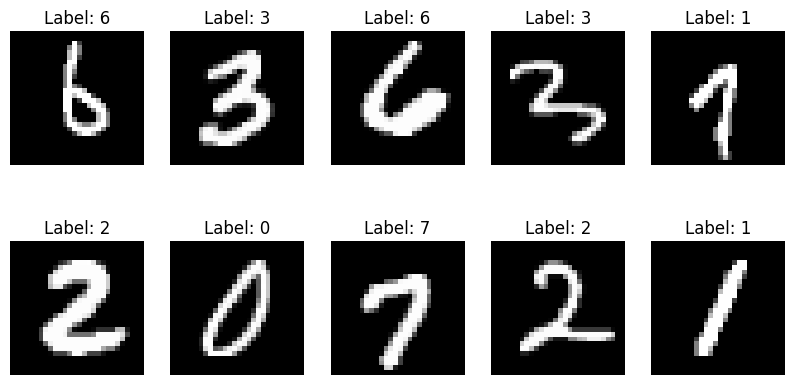

In [7]:
images, labels = next(iter(dataloader))

fig, axes = plt.subplots(2,5, figsize=(10,5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze()
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.show()

In [8]:
class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(100,256),
            nn.ReLU(),

            nn.Linear(256,512),
            nn.ReLU(),

            nn.Linear(512,1024),
            nn.ReLU(),

            nn.Linear(1024,784),
            nn.Tanh()

        )

    def forward(self,x):

        x=self.model(x)

        return x.view(-1,1,28,28)

In [9]:
class Discriminator(nn.Module):

    def __init__(self):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(784,512),
            nn.LeakyReLU(0.2),

            nn.Linear(512,256),
            nn.LeakyReLU(0.2),

            nn.Linear(256,1),
            nn.Sigmoid()

        )

    def forward(self,x):

        x=x.view(-1,784)

        return self.model(x)

In [10]:
generator = Generator().to(device)

discriminator = Discriminator().to(device)

print(generator)

print()

print(discriminator)

Generator(
  (model): Sequential(
    (0): Linear(in_features=100, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): ReLU()
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)

Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [11]:
criterion = nn.BCELoss()

g_optimizer = optim.Adam(
    generator.parameters(),
    lr=0.0002
)

d_optimizer = optim.Adam(
    discriminator.parameters(),
    lr=0.0002
)

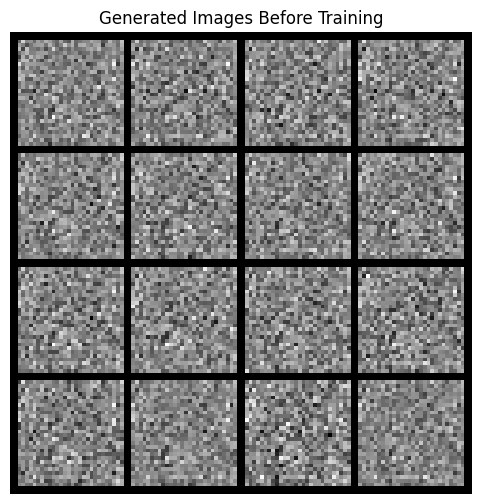

In [12]:
noise = torch.randn(16,100).to(device)

fake_images = generator(noise)

grid = make_grid(fake_images.cpu(), nrow=4, normalize=True)

plt.figure(figsize=(6,6))

plt.imshow(np.transpose(grid,(1,2,0)))

plt.axis("off")

plt.title("Generated Images Before Training")

plt.show()

In [ ]:
epochs = 20

g_losses = []

d_losses = []

for epoch in range(epochs):

    for real_images, _ in dataloader:

        real_images = real_images.to(device)

        batch_size = real_images.size(0)

        real_labels = torch.ones(batch_size,1).to(device)

        fake_labels = torch.zeros(batch_size,1).to(device)

        ###############################
        # Train Discriminator
        ###############################

        noise = torch.randn(batch_size,100).to(device)

        fake_images = generator(noise)

        real_outputs = discriminator(real_images)

        fake_outputs = discriminator(fake_images.detach())

        real_loss = criterion(real_outputs,real_labels)

        fake_loss = criterion(fake_outputs,fake_labels)

        d_loss = real_loss + fake_loss

        d_optimizer.zero_grad()

        d_loss.backward()

        d_optimizer.step()

        ###############################
        # Train Generator
        ###############################

        noise = torch.randn(batch_size,100).to(device)

        fake_images = generator(noise)

        outputs = discriminator(fake_images)

        g_loss = criterion(outputs,real_labels)

        g_optimizer.zero_grad()

        g_loss.backward()

        g_optimizer.step()

    g_losses.append(g_loss.item())

    d_losses.append(d_loss.item())

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"D Loss: {d_loss.item():.4f} | "
        f"G Loss: {g_loss.item():.4f}"
    )

Epoch 1/20 | D Loss: 0.7530 | G Loss: 2.4984
Epoch 2/20 | D Loss: 0.4676 | G Loss: 2.3147
Epoch 3/20 | D Loss: 0.4230 | G Loss: 2.6240
Epoch 4/20 | D Loss: 0.6257 | G Loss: 3.6528
Epoch 5/20 | D Loss: 0.5454 | G Loss: 3.1896
Epoch 6/20 | D Loss: 0.6205 | G Loss: 4.0334
Epoch 7/20 | D Loss: 0.1321 | G Loss: 7.5808
Epoch 8/20 | D Loss: 0.6088 | G Loss: 6.4154
Epoch 9/20 | D Loss: 0.5137 | G Loss: 5.2586


In [ ]:
plt.figure(figsize=(8,5))

plt.plot(g_losses,label="Generator Loss")

plt.plot(d_losses,label="Discriminator Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid()

plt.show()

In [ ]:
generator.eval()

noise = torch.randn(25,100).to(device)

with torch.no_grad():

    generated = generator(noise).cpu()

grid = make_grid(generated,nrow=5,normalize=True)

plt.figure(figsize=(8,8))

plt.imshow(np.transpose(grid,(1,2,0)))

plt.axis("off")

plt.title("Generated Digits")

plt.show()

In [ ]:
torch.save(generator.state_dict(),"generator.pth")

print("Generator Saved Successfully")

# Conclusion

In this notebook, I implemented a basic GAN using PyTorch and trained it on the MNIST dataset.

### Key Learnings

- Understood the architecture of GANs.
- Learned the role of Generator and Discriminator.
- Implemented adversarial training.
- Generated handwritten digit images from random noise.
- Observed how generated images improve over multiple training epochs.